In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Add the experiments/analysis directory to path
sys.path.insert(0, os.path.abspath('../../../../experiments/analysis'))

# Now import
from model_comparison_plots import load_all_results, aggregate_by_county, plot_paired_scatter, plot_bland_altman, plot_raincloud, create_all_plots

In [12]:
def aggregate_by_county(df: pd.DataFrame, metric: str = 'mae') -> pd.DataFrame:
    """
    Aggregate results to county level by computing mean across repetitions and folds.

    Parameters
    ----------
    df : pd.DataFrame
        Raw results dataframe from load_all_results()
    metric : str, default='mae'
        Performance metric to aggregate (e.g., 'mae', 'rmse', 'r2')

    Returns
    -------
    pd.DataFrame
        Aggregated dataframe with columns: fips, model, {metric}_mean
    """
    # Group by county (fips) and model, compute mean of the metric
    # aggregate by metric and train_size
    # agg_dic = {metric: ['mean', 'std'], 'train_size': 'mean' }
    agg_df = df.groupby(['fips', 'model']).agg(
        metric_mean=(metric, 'mean'),
        metric_std=(metric, 'std'),
        train_size_mean=('train_size', 'mean')
    ).reset_index()
    agg_df.columns = ['fips', 'model', f'{metric}_mean', f'{metric}_std', 'train_size_mean']

    # # Pivot to have tabpfn and xgboost as separate columns for easier comparison
    pivot_df = agg_df.pivot(index='fips', columns='model', values=[f'{metric}_mean', f'{metric}_std']).reset_index()
    
    # flatten multi-level columns
    pivot_df.columns = [
        "_".join(col).strip("_") if isinstance(col, tuple) else col
        for col in pivot_df.columns
    ]

    train_sizes = agg_df[['fips', 'train_size_mean']].drop_duplicates()

    pivot_df = pd.merge(pivot_df, train_sizes, on='fips', how='left')

    return pivot_df


In [3]:
df = load_all_results('../')

Loaded 50 files with 5000 total rows


In [13]:
pivot_df = aggregate_by_county(df, 'mae')

In [11]:
pivot_df[pivot_df['xgboost'] < pivot_df['tabpfn']]['fips'].values

array([ 1041,  2185,  8061, 25007, 28009, 28037, 28125, 28163, 29149,
       29199, 30069, 31085])

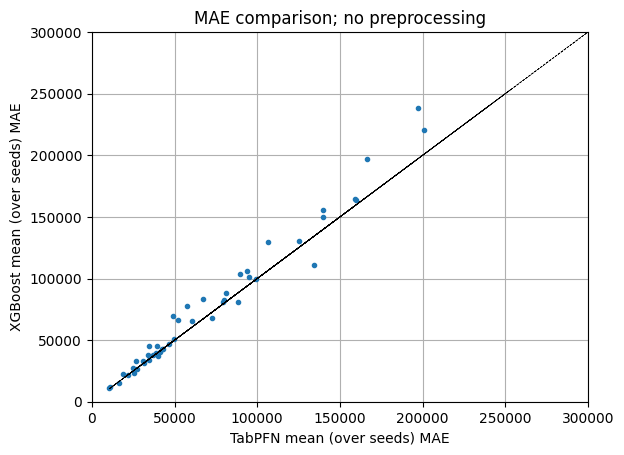

In [17]:
plt.plot(pivot_df['mae_mean_tabpfn'], pivot_df['mae_mean_xgboost'], 'o', markersize=3)
plt.plot(pivot_df['mae_mean_tabpfn'], pivot_df['mae_mean_tabpfn'], 'k--', linewidth=0.5)
plt.xlim(0, 300000)
plt.ylim(0, 300000)
plt.xlabel('TabPFN mean (over seeds) MAE')
plt.ylabel('XGBoost mean (over seeds) MAE')
plt.title('MAE comparison; no preprocessing')
plt.grid()
plt.show()

In [8]:
pivot_df['tabpfn'].describe()

count        50.000000
mean      92521.307490
std      120105.388860
min       10301.006003
25%       34643.720832
50%       54705.094456
75%      104851.839728
max      813105.821557
Name: tabpfn, dtype: float64

In [9]:
pivot_df['xgboost'].describe()

count        50.000000
mean     100664.862538
std      123478.051615
min       11366.718268
25%       37448.553442
50%       67011.195935
75%      109577.704607
max      787296.638256
Name: xgboost, dtype: float64